In [1]:
# Este CSV simulado es lo que encontrarías en el servidor de la empresa
# En la vida real harías: df = pd.read_csv("ventas_2024.csv")
# o: df = pd.read_sql_query("SELECT * FROM ventas", conn)
# Hoy lo creamos así para que puedas practicar sin depender de archivos externos

import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

regiones   = ["CDMX", "Guadalajara", "Monterrey", "Puebla", "Tijuana"]
productos  = ["Laptop", "Monitor", "Teclado", "Mouse", "Auriculares", "Webcam"]
vendedores = [f"Vendedor_{i:02d}" for i in range(1, 16)]

categorias   = {
    "Laptop": "Computo", "Monitor": "Computo",
    "Teclado": "Accesorios", "Mouse": "Accesorios",
    "Auriculares": "Audio", "Webcam": "Audio"
}
precios_base = {
    "Laptop": 18000, "Monitor": 5500, "Teclado": 900,
    "Mouse": 450, "Auriculares": 1200, "Webcam": 850
}

fechas_pool    = pd.date_range("2024-01-01", "2024-12-31", periods=n)
productos_col  = np.random.choice(
    productos, n, p=[0.25, 0.20, 0.15, 0.20, 0.12, 0.08]
)

df = pd.DataFrame({
    "fecha":     np.random.choice(fechas_pool, n),
    "region":    np.random.choice(regiones, n, p=[0.35, 0.25, 0.20, 0.12, 0.08]),
    "producto":  productos_col,
    "categoria": [categorias[p] for p in productos_col],
    "vendedor":  np.random.choice(vendedores, n),
    "unidades":  np.random.randint(1, 20, n),
    "descuento": np.random.choice(
        [0, 0.05, 0.10, 0.15], n, p=[0.50, 0.25, 0.15, 0.10]
    ),
    "precio_unitario": [
        round(precios_base[p] * np.random.uniform(0.85, 1.15), 2)
        for p in productos_col
    ],
})

In [2]:
# Exploración rápida del DataFrame
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            500 non-null    datetime64[ns]
 1   region           500 non-null    object        
 2   producto         500 non-null    object        
 3   categoria        500 non-null    object        
 4   vendedor         500 non-null    object        
 5   unidades         500 non-null    int64         
 6   descuento        500 non-null    float64       
 7   precio_unitario  500 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 31.4+ KB


,fecha,region,producto,categoria,vendedor,unidades,descuento,precio_unitario
0,2024-11-22 05:34:44.969939880,Guadalajara,Monitor,Computo,Vendedor_09,4,0.00,5120.91
1,2024-04-15 07:56:09.138276552,Puebla,Webcam,Audio,Vendedor_12,13,0.00,968.94
2,2024-05-26 07:01:19.358717434,Monterrey,Mouse,Accesorios,Vendedor_15,19,0.05,457.79
3,2024-10-31 06:55:33.066132264,CDMX,Teclado,Accesorios,Vendedor_06,2,0.05,858.76
4,2024-06-03 08:07:41.723446894,CDMX,Laptop,Computo,Vendedor_06,14,0.15,18434.53


In [3]:
# Agregamos columnas para tener diferentes medidas de tiempo
df["mes"] = df["fecha"].dt.month
df["trimestre"] = df["fecha"].dt.quarter
df["mes_nombre"] = df["fecha"].dt.strftime("%B")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   fecha            500 non-null    datetime64[ns]
 1   region           500 non-null    object        
 2   producto         500 non-null    object        
 3   categoria        500 non-null    object        
 4   vendedor         500 non-null    object        
 5   unidades         500 non-null    int64         
 6   descuento        500 non-null    float64       
 7   precio_unitario  500 non-null    float64       
 8   mes              500 non-null    int32         
 9   trimestre        500 non-null    int32         
 10  mes_nombre       500 non-null    object        
dtypes: datetime64[ns](1), float64(2), int32(2), int64(1), object(5)
memory usage: 39.2+ KB


In [4]:
df["venta_bruta"] = df["unidades"] * df["precio_unitario"]
df["descuento_mxn"] = df["venta_bruta"] * df["descuento"]
df["venta_neta"] = df["venta_bruta"] - df["descuento_mxn"]
df["margen"] = df["venta_neta"] * 0.38  # Asumamos un margen del 38% sobre la venta neta

print("Venta Bruta:")
display(df["venta_bruta"].describe())
print(f"--" * 30)
print("\nDescuento en MXN:")
display(df["descuento_mxn"].describe())
print(f"--" * 30)
print("\nVenta Neta:")
display(df["venta_neta"].describe())
print(f"--" * 30)
print("\nMargen:")
display(df["margen"].describe())

Venta Bruta:


count       500.000000
mean      56441.333740
std       83567.736128
min         388.830000
25%        6006.300000
50%       15527.515000
75%       72518.670000
max      391370.360000
Name: venta_bruta, dtype: float64

------------------------------------------------------------

Descuento en MXN:


count      500.000000
mean      2240.144410
std       5412.902939
min          0.000000
25%          0.000000
50%          0.000000
75%       1026.429000
max      38712.513000
Name: descuento_mxn, dtype: float64

------------------------------------------------------------

Venta Neta:


count       500.000000
mean      54201.189330
std       80767.393048
min         349.947000
25%        5722.592000
50%       14586.014250
75%       68925.981000
max      391370.360000
Name: venta_neta, dtype: float64

------------------------------------------------------------

Margen:


count       500.000000
mean      20596.451945
std       30691.609358
min         132.979860
25%        2174.584960
50%        5542.685415
75%       26191.872780
max      148720.736800
Name: margen, dtype: float64

In [5]:
import sqlite3
conn = sqlite3.connect(":memory:")
df.to_sql("ventas", conn, index=False, if_exists="replace")
query = "SELECT region," \
"ROUND(SUM(venta_neta), 2) AS total_venta_neta," \
"ROUND(AVG(venta_neta), 2) AS avg_venta_neta," \
"ROUND(SUM(venta_neta) * 100 / (SELECT SUM(venta_neta) FROM ventas), 2) AS prc_region_totalventas " \
"FROM ventas group by region order by total_venta_neta desc;"
result = pd.read_sql_query(query, conn)
print("Ventas netas por región:")
display(result)

Ventas netas por región:


,region,total_venta_neta,avg_venta_neta,prc_region_totalventas
0,CDMX,9009590.77,50901.64,33.24
1,Guadalajara,6966966.60,61654.57,25.71
2,Monterrey,5537439.74,53244.61,20.43
3,Puebla,3211667.64,51801.09,11.85
4,Tijuana,2374929.91,53975.68,8.76


In [6]:
query2 = "SELECT producto,categoria," \
"round(SUM(venta_neta), 2) AS total_venta_neta," \
"ROUND(AVG(margen), 2) AS avg_margen_producto, " \
"rank() OVER (order by sum(venta_neta) desc) AS rank_producto " \
"FROM ventas group by producto,categoria;"
result2 = pd.read_sql_query(query2, conn)
print("Ventas netas y margen promedio por producto:")
display(result2)

Ventas netas y margen promedio por producto:


,producto,categoria,total_venta_neta,avg_margen_producto,rank_producto
0,Laptop,Computo,20079804.25,58694.81,1
1,Monitor,Computo,4819856.76,19694.04,2
2,Auriculares,Audio,783262.24,4800.64,3
3,Teclado,Accesorios,585997.16,3181.13,4
4,Webcam,Audio,416446.76,3596.59,5
5,Mouse,Accesorios,415227.48,1562.24,6


In [7]:
query3 = "with ventas_mes as (SELECT mes,ROUND(SUM(venta_neta), 2) as total_ventas FROM ventas GROUP BY mes) " \
"SELECT vm.mes, vm.total_ventas, " \
"ROUND(LAG(vm.total_ventas) OVER (ORDER BY vm.mes), 2) AS ventas_mes_anterior, " \
"ROUND((vm.total_ventas - LAG(vm.total_ventas) OVER (ORDER BY vm.mes)), 2) AS cambio_mes_anterior, " \
"ROUND(((vm.total_ventas - LAG(vm.total_ventas) over (order by vm.mes)) / LAG(vm.total_ventas) OVER (ORDER BY vm.mes)) * 100, 2) AS prc_cambio_mes_anterior " \
"FROM ventas_mes vm ;"   
result3 = pd.read_sql_query(query3, conn)
print("Ventas netas por mes con comparación al mes anterior:")
display(result3)

Ventas netas por mes con comparación al mes anterior:


,mes,total_ventas,ventas_mes_anterior,cambio_mes_anterior,prc_cambio_mes_anterior
0,1,2518520.73,NaN,NaN,NaN
1,2,2812476.33,2518520.73,293955.60,11.67
2,3,2924271.85,2812476.33,111795.52,3.97
3,4,2251306.59,2924271.85,-672965.26,-23.01
4,5,813722.64,2251306.59,-1437583.95,-63.86
5,6,2388872.18,813722.64,1575149.54,193.57
6,7,2738942.26,2388872.18,350070.08,14.65
7,8,1987419.40,2738942.26,-751522.86,-27.44
8,9,3073495.40,1987419.40,1086076.00,54.65
9,10,1620352.96,3073495.40,-1453142.44,-47.28


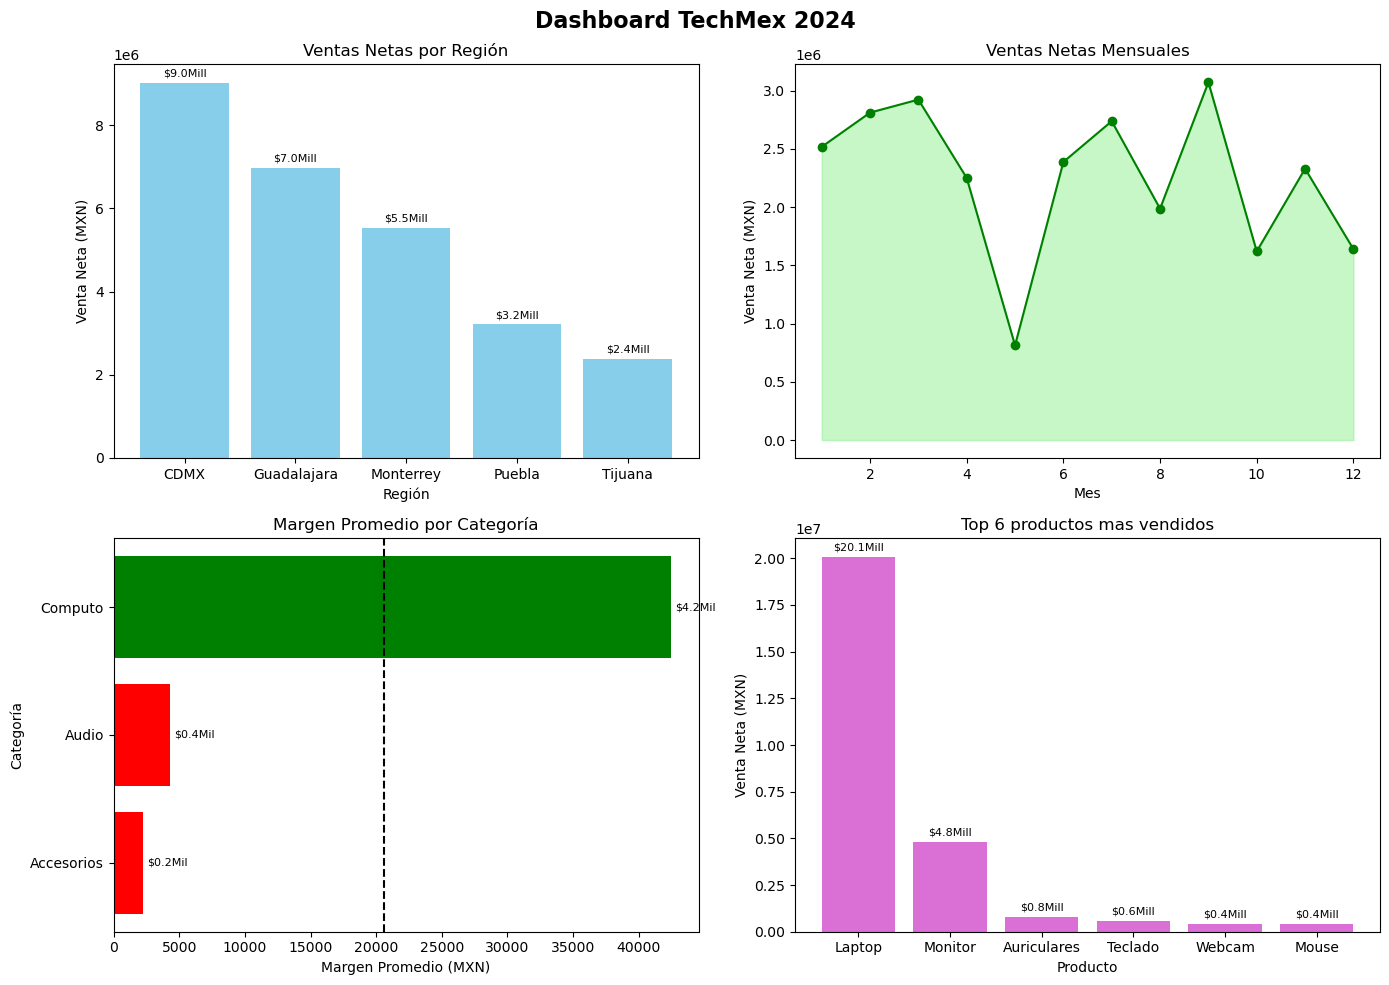

In [15]:
import matplotlib.pyplot as plt

# Una figura con 4 gráficas en cuadrícula 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Dashboard TechMex 2024", fontsize=16, fontweight="bold")

# Gráfica 1 — axes[0,0]: barras por región
# Necesitas: df agrupado por región con suma de venta_neta
axes[0,0].bar(result["region"], result["total_venta_neta"], color="skyblue")
axes[0,0].set_title("Ventas Netas por Región")
axes[0,0].set_xlabel("Región")
axes[0,0].set_ylabel("Venta Neta (MXN)")
for container in axes[0,0].containers:
    axes[0,0].bar_label(container,
        labels=[f"${v/1e6:.1f}Mill" for v in result["total_venta_neta"]],
        padding=3, fontsize=8)
# Gráfica 2 — axes[0,1]: línea mensual
# Necesitas: df agrupado por mes con suma de venta_neta
axes[0,1].plot(result3["mes"], result3["total_ventas"], marker="o", color="green")
axes[0,1].set_title("Ventas Netas Mensuales")
axes[0,1].set_xlabel("Mes")
axes[0,1].set_ylabel("Venta Neta (MXN)")
axes[0,1].fill_between(result3["mes"], result3["total_ventas"], color="lightgreen", alpha=0.5)


# Gráfica 3 — axes[1,0]: barras horizontales por categoría
# Necesitas: df agrupado por categoría con promedio de margen_pct
promedio_margen = df["margen"].mean()
df_cat = df.groupby("categoria")["margen"].mean().reset_index()
color = ['red' if x < promedio_margen else 'green' for x in df_cat["margen"]]
axes[1,0].barh(df_cat["categoria"], df_cat["margen"], color=color)
axes[1,0].set_title("Margen Promedio por Categoría")
axes[1,0].set_xlabel("Margen Promedio (MXN)")
axes[1,0].set_ylabel("Categoría")
#agregamos linea para marcar el promedio
axes[1,0].axvline(promedio_margen, color="black", linestyle="--", label=f"Promedio: {promedio_margen:.2f}")
for container in axes[1,0].containers:
    axes[1,0].bar_label(container,
        labels=[f"${v/1e4:.1f}Mil" for v in df_cat["margen"]],
        padding=3, fontsize=8)
    
# Gráfica 4 — axes[1,1]: barras por producto
# Puedes usar el resultado2 ya corregido del query
axes[1,1].bar(result2["producto"], result2["total_venta_neta"], color="orchid")
axes[1,1].set_title("Top 6 productos mas vendidos")
axes[1,1].set_xlabel("Producto")
axes[1,1].set_ylabel("Venta Neta (MXN)")   
for container in axes[1,1].containers:
    axes[1,1].bar_label(container,
        labels=[f"${v/1e6:.1f}Mill" for v in result2["total_venta_neta"]],
        padding=3, fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
import io
from openpyxl.drawing.image import Image as XLImage
buffer = io.BytesIO()
fig.savefig(buffer, format="png", dpi=300)
buffer.seek(0)
plt.close(fig)




In [10]:

with pd.ExcelWriter("./Reporte_TechMex_2024_2.xlsx") as writer:
    result.to_excel(writer, sheet_name="Por Región", index=False)
    result2.to_excel(writer, sheet_name="por Producto", index=False)
    result3.to_excel(writer, sheet_name="Por Mes", index=False)
    df.to_excel(writer, sheet_name="Data completa", index=False)
    
    wb = writer.book
    ws = wb.create_sheet("Dashboard", 0)
    img = XLImage(buffer)
    img.width = 900
    img.height = 650
    ws.add_image(img, "B2")

print("Reporte exportado a 'Reporte_TechMex_2024_2.xlsx' con las hojas: 'Por Región', 'por Producto', 'Por Mes' y 'Data completa'.")


Reporte exportado a 'Reporte_TechMex_2024_2.xlsx' con las hojas: 'Por Región', 'por Producto', 'Por Mes' y 'Data completa'.
